### import libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

#### Load data to Dataframe

In [3]:
df_applications = pd.read_csv('datasets/applications.csv')
df_branches = pd.read_csv('datasets/branches.csv')
df_customers = pd.read_csv('datasets/customers.csv')
df_defaults = pd.read_csv('datasets/defaults.csv')
df_loans = pd.read_csv('datasets/loans.csv')
df_transactions = pd.read_csv('datasets/transactions.csv')

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\1004027903.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_applications = pd.read_csv('datasets/applications.csv')


In [4]:
df_transactions.head()

,Transaction_ID,Loan_ID,Customer_ID,Transaction_Date,Payment_Type,Amount,Overdue_Fee,Remaining_Balance,Mode_of_Payment
0,T00000001,L005588,C050792,2021-04-30,EMI,46099,1313,1513669,NEFT
1,T00000002,L019942,C008919,2021-12-14,Penalty,43648,4852,901455,UPI
2,T00000003,L014848,C016745,2021-01-26,EMI,1810,0,1922629,Cash
3,T00000004,L041104,C039957,2021-02-18,Penalty,8607,708,213581,UPI
4,T00000005,L002488,C056156,2024-12-07,Penalty,34720,0,411621,UPI


#### 1. Data Quality and Preparation

##### Validate and clean the datasets. 

In [5]:
df_applications[df_applications.isna() & df_applications.isnull()]
df_branches[df_branches.isna() & df_branches.isnull()]
df_branches[df_branches.isna()].describe()
df_branches[df_branches.isnull()]
df_branches[df_branches.notnull()]
df_customers[df_customers.isna() & df_customers.isnull()]
df_defaults[df_defaults.isna() & df_defaults.isnull()]
df_loans[df_loans.isna() & df_loans.isnull()]
df_transactions[df_transactions.isna() & df_transactions.isnull()]


df_applications.head()

,Application_ID,Loan_ID,Customer_ID,Application_Date,Approval_Date,Loan_Purpose,Source_Channel,Processing_Fee,Approval_Status,Rejection_Reason
0,A000001,L000001,C000001,2022-05-11,2020-10-02,Business,Agent,6427,Approved,NaN
1,A000002,L000002,C000002,2022-03-18,2022-11-29,Education,Online,8605,Approved,NaN
2,A000003,L000003,C000003,2022-01-17,2023-07-01,Business,Online,1450,Approved,NaN
3,A000004,L000004,C000004,2019-03-09,2024-08-30,Home Renovation,Agent,8171,Approved,NaN
4,A000005,L000005,C000005,2024-07-18,2020-03-18,Education,Branch,4931,Approved,NaN


##### Check for missing values, duplicate entries, and inconsistent data. 

In [6]:
df_applications.dropna()
df_branches.dropna()
df_customers.dropna()
df_defaults.dropna()
df_loans.dropna()
df_transactions.dropna()

df_applications[df_applications.isna() & df_applications.isnull()].describe()
df_branches[df_branches.isna() & df_branches.isnull()].describe()
df_customers[df_customers.isna() & df_customers.isnull()].describe()
df_defaults[df_defaults.isna() & df_defaults.isnull()].describe()
df_loans[df_loans.isna() & df_loans.isnull()].describe()
df_transactions[df_transactions.isna() & df_transactions.isnull()].describe()

df_applications.describe()
df_branches.describe()
df_customers.describe()
df_defaults.describe()
df_loans.describe()
df_transactions.describe()


,Amount,Overdue_Fee,Remaining_Balance
count,495000.000000,495000.000000,4.950000e+05
mean,25496.424349,1273.332887,9.989344e+05
std,14144.028106,1619.499932,5.776088e+05
min,1000.000000,0.000000,2.000000e+00
25%,13280.000000,0.000000,4.979725e+05
50%,25487.000000,0.000000,9.976355e+05
75%,37730.000000,2539.000000,1.499331e+06
max,50000.000000,5000.000000,1.999999e+06


##### Standardize date formats and remove irrelevant columns.

In [7]:
df_applications.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Application_ID    82600 non-null  object
 1   Loan_ID           70000 non-null  object
 2   Customer_ID       82600 non-null  object
 3   Application_Date  82600 non-null  object
 4   Approval_Date     70000 non-null  object
 5   Loan_Purpose      82600 non-null  object
 6   Source_Channel    82600 non-null  object
 7   Processing_Fee    82600 non-null  int64 
 8   Approval_Status   82600 non-null  object
 9   Rejection_Reason  12600 non-null  object
dtypes: int64(1), object(9)
memory usage: 6.3+ MB


In [8]:
df_applications['Application_Date'] = pd.to_datetime(df_applications['Application_Date'])

In [9]:
df_applications.info()
df_applications.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Application_ID    82600 non-null  object        
 1   Loan_ID           70000 non-null  object        
 2   Customer_ID       82600 non-null  object        
 3   Application_Date  82600 non-null  datetime64[ns]
 4   Approval_Date     70000 non-null  object        
 5   Loan_Purpose      82600 non-null  object        
 6   Source_Channel    82600 non-null  object        
 7   Processing_Fee    82600 non-null  int64         
 8   Approval_Status   82600 non-null  object        
 9   Rejection_Reason  12600 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 6.3+ MB


,Application_ID,Loan_ID,Customer_ID,Application_Date,Approval_Date,Loan_Purpose,Source_Channel,Processing_Fee,Approval_Status,Rejection_Reason
0,A000001,L000001,C000001,2022-05-11,2020-10-02,Business,Agent,6427,Approved,NaN
1,A000002,L000002,C000002,2022-03-18,2022-11-29,Education,Online,8605,Approved,NaN
2,A000003,L000003,C000003,2022-01-17,2023-07-01,Business,Online,1450,Approved,NaN
3,A000004,L000004,C000004,2019-03-09,2024-08-30,Home Renovation,Agent,8171,Approved,NaN
4,A000005,L000005,C000005,2024-07-18,2020-03-18,Education,Branch,4931,Approved,NaN


In [10]:
df_applications.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Application_ID    82600 non-null  object        
 1   Loan_ID           70000 non-null  object        
 2   Customer_ID       82600 non-null  object        
 3   Application_Date  82600 non-null  datetime64[ns]
 4   Approval_Date     70000 non-null  object        
 5   Loan_Purpose      82600 non-null  object        
 6   Source_Channel    82600 non-null  object        
 7   Processing_Fee    82600 non-null  int64         
 8   Approval_Status   82600 non-null  object        
 9   Rejection_Reason  12600 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 6.3+ MB


In [11]:
df_applications['Approval_Date'] = pd.to_datetime(df_applications['Approval_Date'])

In [12]:
df_applications.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Application_ID    82600 non-null  object        
 1   Loan_ID           70000 non-null  object        
 2   Customer_ID       82600 non-null  object        
 3   Application_Date  82600 non-null  datetime64[ns]
 4   Approval_Date     70000 non-null  datetime64[ns]
 5   Loan_Purpose      82600 non-null  object        
 6   Source_Channel    82600 non-null  object        
 7   Processing_Fee    82600 non-null  int64         
 8   Approval_Status   82600 non-null  object        
 9   Rejection_Reason  12600 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(7)
memory usage: 6.3+ MB


In [13]:
df_branches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Branch_ID                   50 non-null     object
 1   Branch_Name                 50 non-null     object
 2   Region                      50 non-null     object
 3   Total_Customers             50 non-null     int64 
 4   Total_Active_Loans          50 non-null     int64 
 5   Delinquent_Loans            50 non-null     int64 
 6   Loan_Disbursement_Amount    50 non-null     int64 
 7   Avg_Processing_Time         50 non-null     int64 
 8   Relationship_Manager_Count  50 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 3.6+ KB


In [14]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer_ID              70000 non-null  object
 1   Full_Name                70000 non-null  object
 2   Contact_Number           70000 non-null  int64 
 3   Email                    70000 non-null  object
 4   Address                  70000 non-null  object
 5   Age                      70000 non-null  int64 
 6   Gender                   70000 non-null  object
 7   Marital_Status           70000 non-null  object
 8   Employment_Status        70000 non-null  object
 9   Annual_Income            70000 non-null  int64 
 10  Credit_Score             70000 non-null  int64 
 11  Region                   70000 non-null  object
 12  Account_Tenure           70000 non-null  object
 13  Relationship_Manager_ID  70000 non-null  object
dtypes: int64(4), object(10)
memory usage: 

In [15]:
df_defaults.info()
df_defaults['Default_Date'] = pd.to_datetime(df_defaults['Default_Date'])

df_defaults.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Default_ID       9000 non-null   object
 1   Loan_ID          9000 non-null   object
 2   Customer_ID      9000 non-null   object
 3   Default_Date     9000 non-null   object
 4   Default_Amount   9000 non-null   int64 
 5   Default_Reason   9000 non-null   object
 6   Recovery_Status  6015 non-null   object
 7   Recovery_Amount  9000 non-null   int64 
 8   Legal_Action     9000 non-null   object
dtypes: int64(2), object(7)
memory usage: 632.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Default_ID       9000 non-null   object        
 1   Loan_ID          9000 non-null   object        
 2   Customer_ID      9000 no

In [16]:
df_loans.info()
df_loans['Disbursal_Date'] = pd.to_datetime(df_loans['Disbursal_Date'])
df_loans['Repayment_Start_Date'] = pd.to_datetime(df_loans['Repayment_Start_Date'])
df_loans['Repayment_End_Date'] = pd.to_datetime(df_loans['Repayment_End_Date'])

df_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               90000 non-null  object 
 1   Customer_ID           90000 non-null  object 
 2   Loan_Amount           90000 non-null  int64  
 3   Interest_Rate         90000 non-null  float64
 4   Loan_Term             90000 non-null  int64  
 5   Disbursal_Date        90000 non-null  object 
 6   Repayment_Start_Date  90000 non-null  object 
 7   Repayment_End_Date    90000 non-null  object 
 8   Loan_Status           90000 non-null  object 
 9   Overdue_Amount        90000 non-null  int64  
 10  EMI_Amount            90000 non-null  int64  
 11  Collateral_Details    59806 non-null  object 
dtypes: float64(1), int64(4), object(7)
memory usage: 8.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 12 columns):
 #   C

In [17]:
df_transactions.info()
df_transactions['Transaction_Date'] = pd.to_datetime(df_transactions['Transaction_Date'])

df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495000 entries, 0 to 494999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Transaction_ID     495000 non-null  object
 1   Loan_ID            495000 non-null  object
 2   Customer_ID        495000 non-null  object
 3   Transaction_Date   495000 non-null  object
 4   Payment_Type       495000 non-null  object
 5   Amount             495000 non-null  int64 
 6   Overdue_Fee        495000 non-null  int64 
 7   Remaining_Balance  495000 non-null  int64 
 8   Mode_of_Payment    495000 non-null  object
dtypes: int64(3), object(6)
memory usage: 34.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495000 entries, 0 to 494999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Transaction_ID     495000 non-null  object        
 1   Loan_ID            495000 no

##### Handle outliers in numeric columns like Loan_Amount, Interest_Rate, and Default_Amount. 

In [18]:
df_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Loan_ID               90000 non-null  object        
 1   Customer_ID           90000 non-null  object        
 2   Loan_Amount           90000 non-null  int64         
 3   Interest_Rate         90000 non-null  float64       
 4   Loan_Term             90000 non-null  int64         
 5   Disbursal_Date        90000 non-null  datetime64[ns]
 6   Repayment_Start_Date  90000 non-null  datetime64[ns]
 7   Repayment_End_Date    90000 non-null  datetime64[ns]
 8   Loan_Status           90000 non-null  object        
 9   Overdue_Amount        90000 non-null  int64         
 10  EMI_Amount            90000 non-null  int64         
 11  Collateral_Details    59806 non-null  object        
dtypes: datetime64[ns](3), float64(1), int64(4), object(4)
memory usage: 8.2+ M

In [19]:
df_loans['Loan_Amount']

0        4030468
1        3498647
2        4871438
3         541515
4         631036
          ...   
89995    4932615
89996    4493121
89997    4107372
89998     100576
89999    4967379
Name: Loan_Amount, Length: 90000, dtype: int64

In [20]:
df_loans['Loan_Amount'].describe()
#no outliers

count    9.000000e+04
mean     2.516259e+06
std      1.429289e+06
min      5.002600e+04
25%      1.275705e+06
50%      2.510076e+06
75%      3.751702e+06
max      4.999958e+06
Name: Loan_Amount, dtype: float64

In [21]:
df_loans['Interest_Rate'].describe()
#no outliers

count    90000.000000
mean        11.005393
std          2.307139
min          7.000000
25%          9.000000
50%         11.010000
75%         13.010000
max         15.000000
Name: Interest_Rate, dtype: float64

In [22]:
df_defaults['Default_Amount'].describe()
#no outliers

count     9000.000000
mean     52978.639667
std      27460.213066
min       5010.000000
25%      29486.500000
50%      53486.500000
75%      77012.000000
max      99997.000000
Name: Default_Amount, dtype: float64

#### Descriptive Analysis 
##### Summarize and visualize key metrics: 

##### Distribution of Loan_Amount, EMI_Amount, and Credit_Score. 

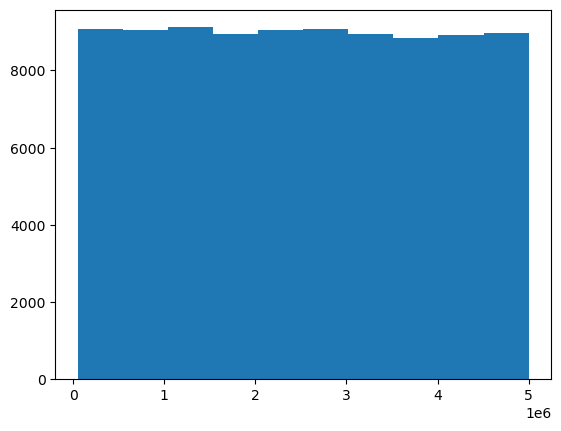

In [23]:
plt.hist(df_loans['Loan_Amount'].astype(int))
plt.show()

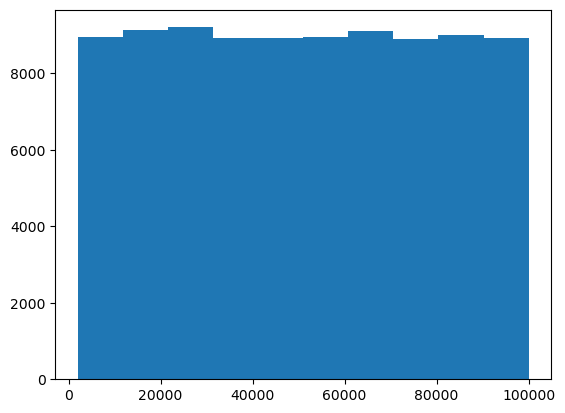

In [24]:
plt.hist(df_loans['EMI_Amount'].astype(int))
plt.show()

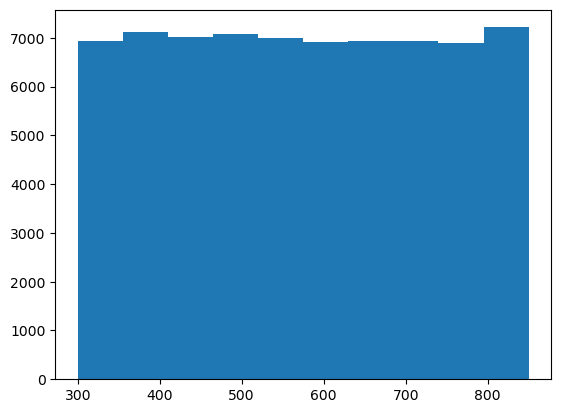

In [25]:
plt.hist(df_customers['Credit_Score'].astype(int))
plt.show()

##### Regional trends in loan disbursement and defaults.

In [26]:
df_customers_loans = pd.merge(df_customers, df_loans, on='Customer_ID', how='inner')

In [27]:
df_customers_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Customer_ID              90000 non-null  object        
 1   Full_Name                90000 non-null  object        
 2   Contact_Number           90000 non-null  int64         
 3   Email                    90000 non-null  object        
 4   Address                  90000 non-null  object        
 5   Age                      90000 non-null  int64         
 6   Gender                   90000 non-null  object        
 7   Marital_Status           90000 non-null  object        
 8   Employment_Status        90000 non-null  object        
 9   Annual_Income            90000 non-null  int64         
 10  Credit_Score             90000 non-null  int64         
 11  Region                   90000 non-null  object        
 12  Account_Tenure           90000 n

Text(0.5, 1.0, 'Regional trends in loan disbursement')

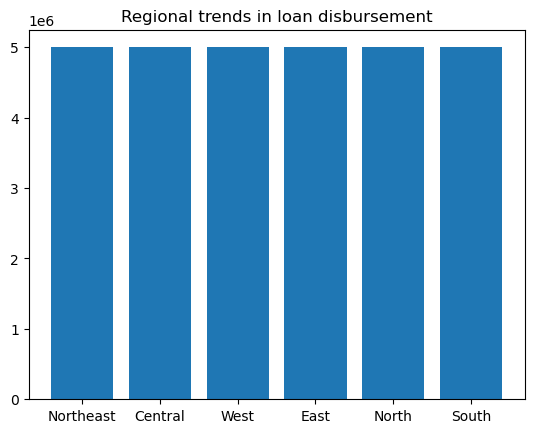

In [28]:
plt.bar(df_customers_loans['Region'], df_customers_loans['Loan_Amount'])
plt.title("Regional trends in loan disbursement")

In [29]:
plt.show()

In [30]:
df_customers_defaults = pd.merge(df_customers, df_defaults, on='Customer_ID', how='left')

In [31]:
df_customers_defaults.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70360 entries, 0 to 70359
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Customer_ID              70360 non-null  object        
 1   Full_Name                70360 non-null  object        
 2   Contact_Number           70360 non-null  int64         
 3   Email                    70360 non-null  object        
 4   Address                  70360 non-null  object        
 5   Age                      70360 non-null  int64         
 6   Gender                   70360 non-null  object        
 7   Marital_Status           70360 non-null  object        
 8   Employment_Status        70360 non-null  object        
 9   Annual_Income            70360 non-null  int64         
 10  Credit_Score             70360 non-null  int64         
 11  Region                   70360 non-null  object        
 12  Account_Tenure           70360 n

In [32]:
df_customers_defaults.groupby('Region')['Default_Amount'].sum()

Region
Central      60166820.0
East         64656315.0
North        62378265.0
Northeast    59756404.0
South        60965366.0
West         64012891.0
Name: Default_Amount, dtype: float64

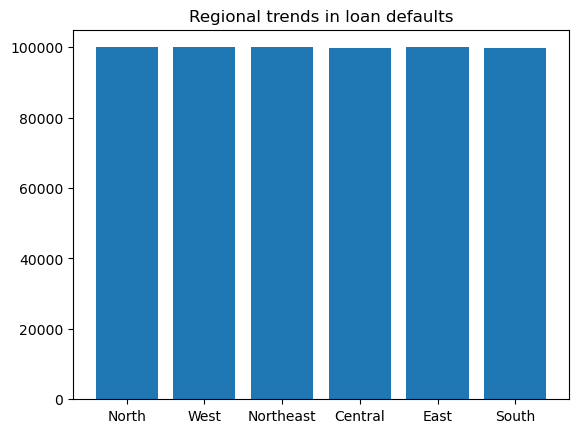

In [33]:
plt.bar(df_customers_defaults['Region'], df_customers_defaults['Default_Amount'])
plt.title("Regional trends in loan defaults")
plt.show()

##### Monthly trends in loan approvals and disbursements.

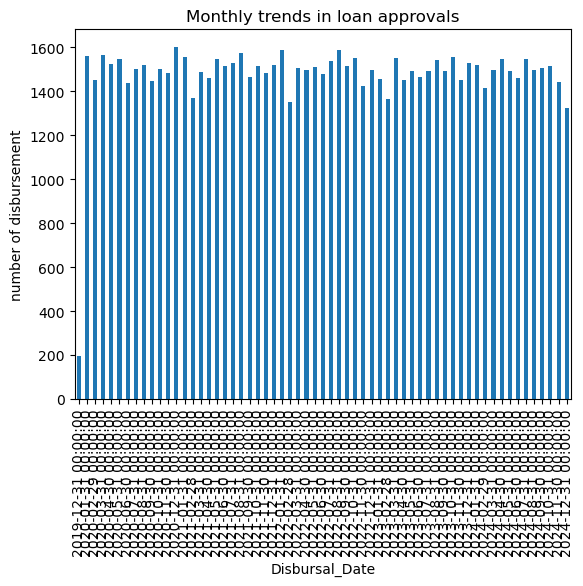

In [34]:
monthly_data=df_loans.groupby(pd.Grouper(key='Disbursal_Date', freq='ME'))['Loan_Amount'].count()

monthly_data.plot(kind='bar')
plt.title("Monthly trends in loan approvals")
plt.ylabel('number of disbursement')
plt.show()

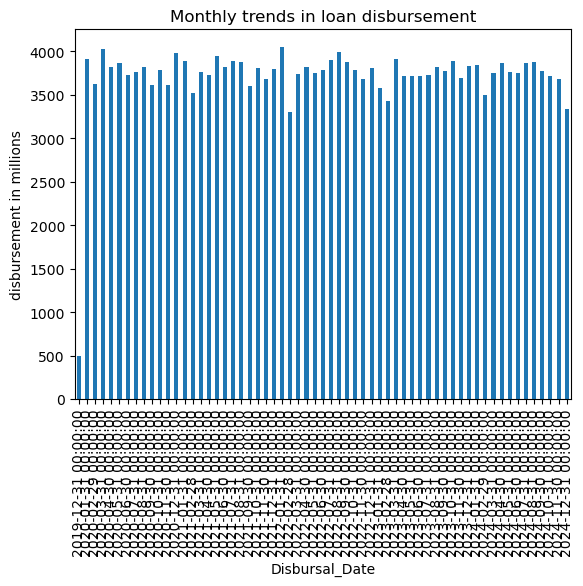

In [35]:
monthly_data=df_loans.groupby(pd.Grouper(key='Disbursal_Date', freq='ME'))['Loan_Amount'].sum()/1000000

monthly_data.plot(kind='bar')
plt.title("Monthly trends in loan disbursement")
plt.ylabel('disbursement in millions')
plt.show()

#### 3. Default Risk Analysis 
#### ● Correlation Between Loan Attributes and Defaults: 
##### o Calculate correlations between Loan_Amount, Interest_Rate, Credit_Score, and Default_Flag (a binary indicator for default). 


In [36]:
#df_customers_loans.info()
data_correlation = df_customers_loans[['Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Credit_Score']]
#data_correlation
df_customer_defaults=df_defaults[['Customer_ID', 'Default_Date']]
#df_customer_defaults
data_correlation_combined = pd.merge(data_correlation, df_customer_defaults, on='Customer_ID', how='left')
data_correlation_combined['default_flag'] = data_correlation_combined['Default_Date'].notna()
#data_correlation_combined[data_correlation_combined['default_flag']==True]
data_correlation_combined.head()

,Customer_ID,Loan_Amount,Interest_Rate,Credit_Score,Default_Date,default_flag
0,C000003,2791233,14.66,736,NaT,False
1,C000003,3402774,9.58,736,NaT,False
2,C000004,3822336,10.69,353,NaT,False
3,C000004,4989836,10.16,353,NaT,False
4,C000004,2347557,8.85,353,NaT,False


In [37]:
data_correlation_combined2 = data_correlation_combined[['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'default_flag']]
data_correlation_combined2.corr()
#data_correlation_combined2.info()
#print(data_correlation)

,Loan_Amount,Interest_Rate,Credit_Score,default_flag
Loan_Amount,1.000000,-0.002973,0.000417,0.000632
Interest_Rate,-0.002973,1.000000,0.002840,0.002923
Credit_Score,0.000417,0.002840,1.000000,0.001243
default_flag,0.000632,0.002923,0.001243,1.000000


#### Pairwise Correlation Analysis: 
##### o Create a heatmap to visualize the correlations between key variables, such as EMI_Amount, Overdue_Amount, and Default_Amount.

In [38]:
#df_customers_loans.info()
data_correlation = df_customers_loans[['Customer_ID', 'EMI_Amount', 'Overdue_Amount']]
#data_correlation
df_customer_defaults=df_defaults[['Customer_ID', 'Default_Amount']]
#df_customer_defaults
data_correlation_combined = pd.merge(data_correlation, df_customer_defaults, on='Customer_ID', how='left')
#data_correlation_combined['default_flag'] = data_correlation_combined['Default_Amount'].notna()
data_correlation_combined = data_correlation_combined.drop(columns=['Customer_ID'])

#data_correlation_combined.corr()

#data_correlation_combined[data_correlation_combined['default_flag']==True]
#data_correlation_combined[data_correlation_combined['default_flag']==True].describe()

In [39]:
data = data_correlation_combined.corr()
for i in range(len(data.columns)):
    data.iloc[i,i]=np.nan

#data = data_correlation_combined[data_correlation_combined['Default_Amount'].notna()]
data.max().max()

0.00725562001732093

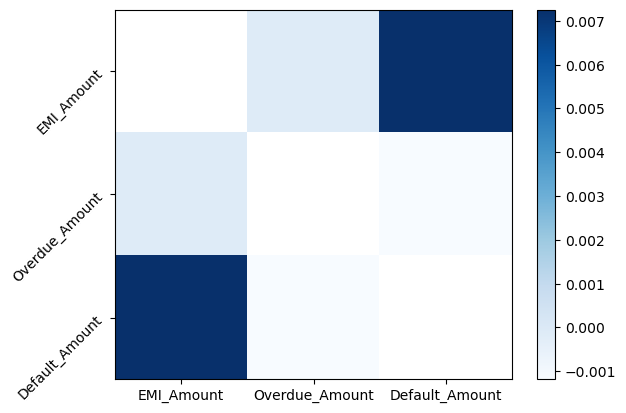

In [40]:
#fig, ax = plt.subplots()
plt.imshow(data, cmap='Blues', aspect='auto', vmin=data.min().min()-0.000005, vmax=data.max().max()+0.0000005)

plt.colorbar()

#plt.set_title("Heatmap")
plt.xticks(range(len(data.columns)),data.columns)
plt.yticks(range(len(data.columns)),data.columns, rotation=45)

plt.show()

#### Correlation Between Branch Metrics and Defaults: 
##### o Analyze the relationship between branch performance metrics (e.g., Delinquent_Loans, Loan_Disbursement_Amount) and default rates.

In [41]:
df_branches_d1 = df_branches[['Delinquent_Loans','Total_Active_Loans']]
#df_branches_d1
df_branches_d1['default rates'] = df_branches['Delinquent_Loans'] / df_branches['Total_Active_Loans']




C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\3662806562.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_branches_d1['default rates'] = df_branches['Delinquent_Loans'] / df_branches['Total_Active_Loans']


In [42]:
df_branches_d1.corr()

,Delinquent_Loans,Total_Active_Loans,default rates
Delinquent_Loans,1.000000,-0.101195,0.473941
Total_Active_Loans,-0.101195,1.000000,-0.599700
default rates,0.473941,-0.599700,1.000000


#### 4. Branch and Regional Performance 
##### ● Rank branches by:

##### Loan disbursement volume.

In [43]:
df_branches_d2 = pd.DataFrame()
df_branches_d2 = df_branches[['Branch_ID', 'Branch_Name', 'Loan_Disbursement_Amount']]
df_branches_d2['Loan_Disbursement_Amount_rank'] = df_branches['Loan_Disbursement_Amount'].rank(ascending=False)

df_branches_d2.head()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\838199876.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_branches_d2['Loan_Disbursement_Amount_rank'] = df_branches['Loan_Disbursement_Amount'].rank(ascending=False)


,Branch_ID,Branch_Name,Loan_Disbursement_Amount,Loan_Disbursement_Amount_rank
0,B001,"Dhar, Kant and Madan",341680882,19.0
1,B002,Shan Group,96549019,40.0
2,B003,Sachdev-Banerjee,445787808,7.0
3,B004,Kapadia-Brar,353934299,18.0
4,B005,"Mangal, Kaur and Borde",311637902,20.0


In [44]:
df_branches_d2.sort_values(by='Loan_Disbursement_Amount_rank')

,Branch_ID,Branch_Name,Loan_Disbursement_Amount,Loan_Disbursement_Amount_rank
35,B036,Kara-Bahl,499562869,1.0
13,B014,"Bhatti, Rau and Sem",482327541,2.0
11,B012,Kaul Inc,465469874,3.0
47,B048,Chawla-Subramanian,464419943,4.0
34,B035,"Malhotra, Boase and Malhotra",449109596,5.0
42,B043,Grover Group,447832443,6.0
2,B003,Sachdev-Banerjee,445787808,7.0
49,B050,Sani-Kale,442594434,8.0
9,B010,Arya Ltd,435407779,9.0
36,B037,Yogi Ltd,420746720,10.0


##### Processing time efficiency

In [45]:
df_branches_d3 = pd.DataFrame()
df_branches_d3 = df_branches[['Branch_ID', 'Branch_Name', 'Avg_Processing_Time']]
df_branches_d3['Avg_Processing_Time_rank'] = df_branches['Avg_Processing_Time'].rank(ascending=True)
df_branches_d3.sort_values(by='Avg_Processing_Time_rank')

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\1702369662.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_branches_d3['Avg_Processing_Time_rank'] = df_branches['Avg_Processing_Time'].rank(ascending=True)


,Branch_ID,Branch_Name,Avg_Processing_Time,Avg_Processing_Time_rank
49,B050,Sani-Kale,1,1.0
46,B047,Chawla-Tandon,2,3.0
41,B042,Kar-Jaggi,2,3.0
17,B018,"Sandhu, Magar and Sachdeva",2,3.0
44,B045,Solanki-Shah,3,6.0
26,B027,Kapadia-Ramakrishnan,3,6.0
11,B012,Kaul Inc,3,6.0
47,B048,Chawla-Subramanian,4,8.0
32,B033,"Saini, Iyer and Sani",5,9.5
22,B023,"Wable, Butala and Kakar",5,9.5


##### Default rates and recovery rates.

In [46]:
df_defaults_d1 = df_defaults[['Default_Amount','Recovery_Amount']]
df_defaults_d1['recovery_rates'] = df_defaults['Recovery_Amount']/df_defaults['Default_Amount']
df_defaults_d1

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\774761421.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_defaults_d1['recovery_rates'] = df_defaults['Recovery_Amount']/df_defaults['Default_Amount']


,Default_Amount,Recovery_Amount,recovery_rates
0,94480,30360,0.321338
1,10912,0,0.000000
2,73711,9866,0.133847
3,48955,0,0.000000
4,56952,0,0.000000
...,...,...,...
8995,29136,23424,0.803954
8996,6612,0,0.000000
8997,56304,38403,0.682065
8998,58524,12863,0.219790


##### Compare branch performance across regions. 

In [47]:
df_branches_d3 = df_branches.groupby('Region')[['Total_Customers','Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time']].mean()
df_branches_d3.head()

,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time
Region,,,,,
Central,3011.200000,871.500000,99.400000,3.316048e+08,9.500000
East,3109.875000,1116.125000,94.500000,2.508345e+08,9.875000
North,2875.785714,854.642857,107.428571,2.354339e+08,10.357143
Northeast,2034.000000,1293.500000,121.750000,1.107070e+08,6.500000
South,2843.250000,1154.375000,105.750000,2.118633e+08,9.000000


#### 5. Customer Segmentation

##### Segment customers by income, credit score, and loan status. 

In [48]:
df_customers_loanstatus_c1 = pd.DataFrame()
#df_customers_loanstatus_c1 = df_customers[['Annual_Income', 'Credit_Score']]
df_customers_loanstatus_c1 = pd.merge(df_customers,df_loans,on='Customer_ID')
df_customers_loanstatus_c1 

#df_customers[['Annual_Income']].describe()

,Customer_ID,Full_Name,Contact_Number,Email,Address,Age,Gender,Marital_Status,Employment_Status,Annual_Income,...,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,EMI_Amount,Collateral_Details
0,C000003,Rhea Bhargava,910320534937,bahlelakshi@mall.info,"67/386\nComar Nagar, Chapra 137669",62,Other,Single,Self-Employed,1118591,...,2791233,14.66,60,2024-06-30,2024-07-30,2029-06-30,Closed,0,28882,NaN
1,C000003,Rhea Bhargava,910320534937,bahlelakshi@mall.info,"67/386\nComar Nagar, Chapra 137669",62,Other,Single,Self-Employed,1118591,...,3402774,9.58,24,2021-01-10,2021-02-10,2023-01-10,Overdue,44073,58437,NaN
2,C000004,Indrans Walia,6566372162,akadakia@yahoo.com,88\nDhillon Ganj\nJamshedpur-816278,59,Female,Single,Salaried,524075,...,3822336,10.69,12,2021-06-01,2021-07-01,2022-06-01,Closed,0,13389,Property
3,C000004,Indrans Walia,6566372162,akadakia@yahoo.com,88\nDhillon Ganj\nJamshedpur-816278,59,Female,Single,Salaried,524075,...,4989836,10.16,24,2021-08-31,2021-09-30,2023-08-31,Overdue,0,37450,NaN
4,C000004,Indrans Walia,6566372162,akadakia@yahoo.com,88\nDhillon Ganj\nJamshedpur-816278,59,Female,Single,Salaried,524075,...,2347557,8.85,36,2023-08-23,2023-09-23,2026-08-23,Active,0,65252,Property
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,C069998,Eshani Ram,9210965566,vedikaranganathan@gmail.com,H.No. 520\nThaman Marg\nPanipat-931124,49,Male,Single,Self-Employed,464958,...,3892899,13.09,24,2023-09-09,2023-10-09,2025-09-09,Overdue,3858,34697,Vehicle
89996,C069999,Shaan Brar,911251433283,ckurian@hotmail.com,14/928\nDin Zila\nNew Delhi-319692,57,Male,Divorced,Salaried,812186,...,2296996,11.84,36,2020-12-22,2021-01-22,2023-12-22,Active,10858,32237,Property
89997,C070000,Amira Mander,4662335677,surikabir@gmail.com,"35, Vala Marg\nOngole-557777",49,Male,Married,Unemployed,1057211,...,2304755,7.01,36,2024-09-18,2024-10-18,2027-09-18,Closed,0,58283,NaN
89998,C070000,Amira Mander,4662335677,surikabir@gmail.com,"35, Vala Marg\nOngole-557777",49,Male,Married,Unemployed,1057211,...,903318,7.40,60,2021-12-29,2022-01-29,2026-12-29,Active,5872,12412,NaN


##### income category

In [49]:
df_customers_loanstatus_c1['Annual_Income'].describe()

count    9.000000e+04
mean     1.100252e+06
std      5.196229e+05
min      2.000570e+05
25%      6.502300e+05
50%      1.099206e+06
75%      1.549499e+06
max      1.999950e+06
Name: Annual_Income, dtype: float64

In [50]:
df_customers_loanstatus_c1['Annual_Income_category'] = pd.cut(df_customers_loanstatus_c1['Annual_Income'],
                         bins = [0, 500000,1500000,3000000],
                         labels = ['Lower Middle class >5L', 'higher Middle clase 5-15L', 'high networth indivuduals >15L <30L'])
df_customers_loanstatus_c1.groupby('Annual_Income_category')['Customer_ID'].count()


C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\1983768565.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_customers_loanstatus_c1.groupby('Annual_Income_category')['Customer_ID'].count()


Annual_Income_category
Lower Middle class >5L                 14960
higher Middle clase 5-15L              50065
high networth indivuduals >15L <30L    24975
Name: Customer_ID, dtype: int64

##### credit score

In [51]:
df_customers_loanstatus_c1['Credit_Score'].describe()

count    90000.000000
mean       574.118878
std        159.187813
min        300.000000
25%        436.000000
50%        573.000000
75%        713.000000
max        850.000000
Name: Credit_Score, dtype: float64

In [52]:
df_customers_loanstatus_c1['Credit_Score_category'] = pd.cut(df_customers_loanstatus_c1['Credit_Score'],
                         bins = [0, 500,715,851],
                         labels = ['Lower score <500', 'Middle score 500-715', 'high score 715-850'])
df_customers_loanstatus_c1.groupby('Credit_Score_category')['Customer_ID'].count()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\2169105129.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_customers_loanstatus_c1.groupby('Credit_Score_category')['Customer_ID'].count()


Credit_Score_category
Lower score <500        33188
Middle score 500-715    34783
high score 715-850      22029
Name: Customer_ID, dtype: int64

##### loan status.

In [53]:
df_customers_loanstatus_c1.groupby('Loan_Status')['Customer_ID'].count()

Loan_Status
Active     30050
Closed     30084
Overdue    29866
Name: Customer_ID, dtype: int64

##### Identify high-risk and high-value customer groups. 

In [54]:
#df_customers_loanstatus_c1.info()
df_customers_loanstatus_c1_overdue = df_customers_loanstatus_c1[df_customers_loanstatus_c1['Loan_Status']=='Overdue']
#df_customers_loanstatus_c1_overdue.info()


In [55]:
#high-risk due to overdue status by Credit score customer group
df_customers_loanstatus_c1_overdue.groupby('Credit_Score_category')['Customer_ID'].count()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\1091131292.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_customers_loanstatus_c1_overdue.groupby('Credit_Score_category')['Customer_ID'].count()


Credit_Score_category
Lower score <500        11022
Middle score 500-715    11592
high score 715-850       7252
Name: Customer_ID, dtype: int64

In [56]:
#high-risk due to Overdue status by Annual Income category customer group
df_customers_loanstatus_c1_overdue.groupby('Annual_Income_category')['Customer_ID'].count()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\2272726366.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_customers_loanstatus_c1_overdue.groupby('Annual_Income_category')['Customer_ID'].count()


Annual_Income_category
Lower Middle class >5L                  4923
higher Middle clase 5-15L              16560
high networth indivuduals >15L <30L     8383
Name: Customer_ID, dtype: int64

#### 6. Advanced Statistical Analysis 
##### 1. Correlation Analysis for Default Risks: 

##### Examine the correlation between Credit_Score, Loan_Amount, Interest_Rate, Overdue_Amount, and Default_Flag. 

In [57]:
df_customers_loanstatus_c1 ['default_flag'] = df_customers_loanstatus_c1['Loan_Status']=='Overdue'
#df_customers_loanstatus_c1.groupby('default_flag')['default_flag'].count()
df_customers_loanstatus_c1_corr = df_customers_loanstatus_c1[['Credit_Score', 'Loan_Amount', 'Interest_Rate', 'Overdue_Amount', 'default_flag']]
df_customers_loanstatus_c1_corr.corr()

,Credit_Score,Loan_Amount,Interest_Rate,Overdue_Amount,default_flag
Credit_Score,1.000000,0.000139,0.002457,0.001570,-0.003382
Loan_Amount,0.000139,1.000000,-0.003201,0.008400,0.003023
Interest_Rate,0.002457,-0.003201,1.000000,-0.002199,-0.002402
Overdue_Amount,0.001570,0.008400,-0.002199,1.000000,0.003228
default_flag,-0.003382,0.003023,-0.002402,0.003228,1.000000


##### Pairwise Correlation Heatmap: 
##### o Generate a heatmap to visualize correlations among key variables like EMI_Amount, Recovery_Rate, and Default_Amount. 

In [58]:
df_loans_defaults_d2 = pd.merge(df_loans,df_defaults,on='Loan_ID', how = 'left')
df_loans_defaults_d2['recovery_rates'] = df_loans_defaults_d2['Recovery_Amount']/df_loans_defaults_d2['Default_Amount']
df_defaults_d1
df_loans_defaults_d2_corr = df_loans_defaults_d2[['EMI_Amount', 'recovery_rates', 'Default_Amount']].corr()


df_loans_defaults_d2_corr

,EMI_Amount,recovery_rates,Default_Amount
EMI_Amount,1.000000,-0.008247,0.007650
recovery_rates,-0.008247,1.000000,-0.374882
Default_Amount,0.007650,-0.374882,1.000000


In [59]:
data = df_loans_defaults_d2_corr
for i in range(len(data.columns)):
    data.iloc[i,i]=np.nan

#data = data_correlation_combined[data_correlation_combined['Default_Amount'].notna()]
#data.max().max()

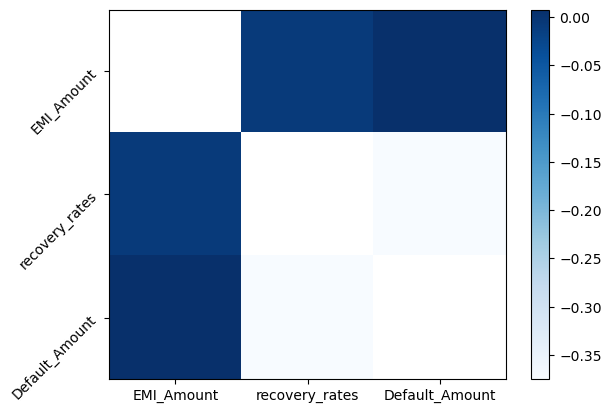

In [60]:
plt.imshow(data, cmap='Blues', aspect='auto', vmin=data.min().min()-0.000005, vmax=data.max().max()+0.0000005)

plt.colorbar()

#plt.set_title("Heatmap")
plt.xticks(range(len(data.columns)),data.columns)
plt.yticks(range(len(data.columns)),data.columns, rotation=45)

plt.show()

#### Branch-Level Correlation: 
##### o Explore the relationship between branch performance metrics (Delinquent_Loans, Loan_Disbursement_Amount, Recovery_Rate) and overall efficiency.

#### Transaction and Recovery Analysis

##### Analyze penalty payments and overdue trends. 

In [61]:
df_transactions_defaults_d1 = pd.merge(df_transactions, df_defaults, on='Loan_ID', how='left')
df_transactions_defaults_d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497552 entries, 0 to 497551
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Transaction_ID     497552 non-null  object        
 1   Loan_ID            497552 non-null  object        
 2   Customer_ID_x      497552 non-null  object        
 3   Transaction_Date   497552 non-null  datetime64[ns]
 4   Payment_Type       497552 non-null  object        
 5   Amount             497552 non-null  int64         
 6   Overdue_Fee        497552 non-null  int64         
 7   Remaining_Balance  497552 non-null  int64         
 8   Mode_of_Payment    497552 non-null  object        
 9   Default_ID         49407 non-null   object        
 10  Customer_ID_y      49407 non-null   object        
 11  Default_Date       49407 non-null   datetime64[ns]
 12  Default_Amount     49407 non-null   float64       
 13  Default_Reason     49407 non-null   object  

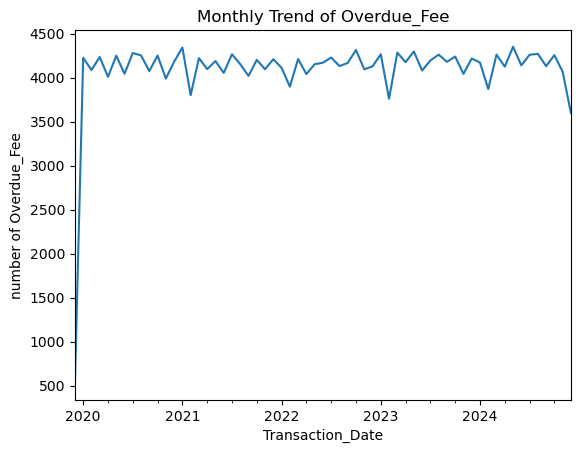

In [62]:
df_transactions_defaults_d1_penalty = df_transactions_defaults_d1[df_transactions_defaults_d1['Payment_Type']=='Penalty']
monthly_data=df_transactions_defaults_d1_penalty.groupby(pd.Grouper(key='Transaction_Date', freq='ME'))['Overdue_Fee'].count()

monthly_data.plot(kind='line')
plt.title("Monthly Trend of Overdue_Fee")
plt.ylabel('number of Overdue_Fee')
plt.show()

#plt.plot(df_transactions_defaults_d1['Transaction_Date'], df_transactions_defaults_d1, label = 'Trend of Overdue_Fee')

##### Evaluate recovery rates by Default_Reason and Legal_Action. 

In [63]:
#df_loans_defaults_d2.info()
df_loans_defaults_d2.groupby(['Default_Reason', 'Legal_Action'])['Default_ID'].count()

Default_Reason     Legal_Action
Business Failure   No              1135
                   Yes             1150
Job Loss           No              1077
                   Yes             1083
Medical Emergency  No              1179
                   Yes             1083
Other              No              1159
                   Yes             1134
Name: Default_ID, dtype: int64

##### Compare recovery rates across regions and branches. 

In [64]:
df_customer_loans = pd.merge(df_customers, df_loans, on='Customer_ID', how='left')
df_customer_loans_defaults = pd.merge(df_customer_loans, df_defaults, on='Loan_ID', how='left')
df_customer_loans_defaults_g1 = df_customer_loans_defaults[df_customer_loans_defaults['Recovery_Amount'].notna()]
df_customer_loans_defaults_g1['recovery_rate'] = df_customer_loans_defaults_g1['Recovery_Amount'] / df_customer_loans_defaults_g1['Overdue_Amount']
df_customer_loans_defaults_g1.groupby('Region')['Recovery_Amount'].sum() / df_customer_loans_defaults_g1.groupby('Region')['Overdue_Amount'].sum()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\3809458989.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_customer_loans_defaults_g1['recovery_rate'] = df_customer_loans_defaults_g1['Recovery_Amount'] / df_customer_loans_defaults_g1['Overdue_Amount']


Region
Central      1.010534
East         0.999479
North        1.014052
Northeast    1.054802
South        1.013664
West         0.968839
dtype: float64

#### EMI Analysis 

##### Analyze the relationship between EMI amounts and default probabilities.

In [65]:
df_customer_loans_defaults['EMI_Amount'].describe()
#df_customer_loans_defaults.info()

count     90461.000000
mean      50870.151966
std       28273.361362
min        2001.000000
25%       26230.000000
50%       50845.000000
75%       75426.000000
max      100000.000000
Name: EMI_Amount, dtype: float64

In [66]:
df_customer_loans_defaults['EMI_Amount_category'] = pd.cut(df_customer_loans_defaults['EMI_Amount'],
                         bins = [0, 25000,50000,75000,100000],
                         labels = ['0-25k', '25k-50k', '50k-75k', '75k-100k'])
df_customer_loans_defaults_rates = df_customer_loans_defaults.groupby('EMI_Amount_category')['Default_Amount'].sum() / df_customer_loans_defaults.groupby('EMI_Amount_category')['EMI_Amount'].sum()
df_customer_loans_defaults_rates 

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\154395661.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_customer_loans_defaults_rates = df_customer_loans_defaults.groupby('EMI_Amount_category')['Default_Amount'].sum() / df_customer_loans_defaults.groupby('EMI_Amount_category')['EMI_Amount'].sum()


EMI_Amount_category
0-25k       0.386374
25k-50k     0.136884
50k-75k     0.086728
75k-100k    0.060633
dtype: float64

##### Identify thresholds for EMI amounts where defaults are most likely. 

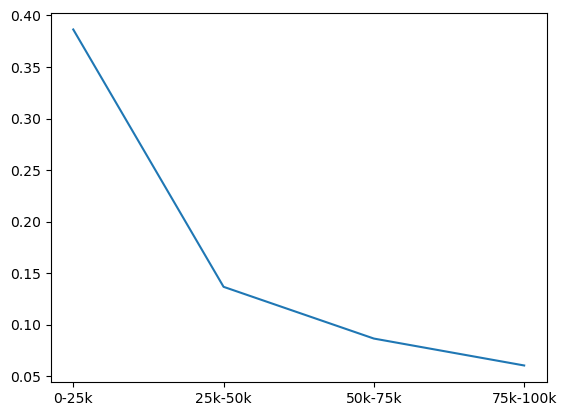

In [67]:
plt.plot(df_customer_loans_defaults_rates)

##### Compare EMI trends across loan types.

In [68]:
df_customer_loans_defaults.groupby(['EMI_Amount_category','Collateral_Details'])['EMI_Amount'].count()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\2225079375.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_customer_loans_defaults.groupby(['EMI_Amount_category','Collateral_Details'])['EMI_Amount'].count()


EMI_Amount_category  Collateral_Details
0-25k                Property              7047
                     Vehicle               7104
25k-50k              Property              7737
                     Vehicle               7686
50k-75k              Property              7535
                     Vehicle               7632
75k-100k             Property              7751
                     Vehicle               7622
Name: EMI_Amount, dtype: int64

### 9 Loan Application Insights

##### Calculate approval and rejection rates for loan applications.

In [69]:
#df_applications.info()
df_applications_rejection = df_applications[df_applications['Approval_Status']=='Rejected']
df_applications_rejection.groupby('Loan_Purpose')['Approval_Status'].count() / df_applications.groupby('Loan_Purpose')['Customer_ID'].count()*100

Loan_Purpose
Business           15.274246
Education          14.723477
Home Renovation    15.647981
Personal           15.328556
Vehicle            15.290795
dtype: float64

In [70]:
df_applications_rejection = df_applications[df_applications['Approval_Status']=='Approved']
df_applications_rejection.groupby('Loan_Purpose')['Approval_Status'].count() / df_applications.groupby('Loan_Purpose')['Customer_ID'].count()*100

Loan_Purpose
Business           84.725754
Education          85.276523
Home Renovation    84.352019
Personal           84.671444
Vehicle            84.709205
dtype: float64

##### Identify the most common reasons for loan rejection. 

In [71]:
df_applications_Rejection_Reason = df_applications.groupby('Rejection_Reason')['Customer_ID'].count()
df_applications_Rejection_Reason.sort_values(ascending=False)

Rejection_Reason
Low Credit Score        4297
Incomplete Documents    4204
Insufficient Income     4099
Name: Customer_ID, dtype: int64

##### Compare application processing fees between approved and rejected applications.

In [72]:
#df_applications['Processing_Fee'].describe()
df_applications['Processing_Fee_category'] = pd.cut(df_applications['Processing_Fee'],
                         bins = [0, 1000,3000,6000,10000],
                         labels = ['0-1k', '1k-3k', '3k-6k', '6k-10k'])
df_applications.groupby(['Approval_Status','Processing_Fee_category'])['Customer_ID'].count()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\1764635098.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_applications.groupby(['Approval_Status','Processing_Fee_category'])['Customer_ID'].count()


Approval_Status  Processing_Fee_category
Approved         0-1k                        3800
                 1k-3k                      14466
                 3k-6k                      22222
                 6k-10k                     29512
Rejected         0-1k                         622
                 1k-3k                       2661
                 3k-6k                       3995
                 6k-10k                      5322
Name: Customer_ID, dtype: int64

#### 10. Recovery Effectiveness
##### ● Determine the effectiveness of recovery efforts by calculating the ratio of Recovery_Amount to Default_Amount.

In [73]:
df_defaults_recovery = df_defaults.groupby('Legal_Action')[['Recovery_Amount', 'Default_Amount']].sum()
df_defaults_recovery_rate = df_defaults_recovery['Recovery_Amount'] / df_defaults_recovery['Default_Amount']
df_defaults_recovery_rate

Legal_Action
No     0.241476
Yes    0.244808
dtype: float64

##### ● Compare recovery rates for defaults with and without legal actions.

In [74]:
#df_defaults_recovery_rate
df_defaults_recovery_rate['Yes']

np.float64(0.24480834994619202)

#### 11. Loan Disbursement Efficiency
##### ● Analyze the time from application to loan disbursement and identify bottlenecks.

In [75]:
df_applications_loans = pd.merge(df_applications, df_loans, on='Customer_ID', how='inner')
df_applications_loans['processing_times'] = df_applications_loans['Disbursal_Date'] - df_applications_loans['Application_Date']
df_applications_loans.groupby('Rejection_Reason')['Customer_ID'].count()

Rejection_Reason
Incomplete Documents    5347
Insufficient Income     5226
Low Credit Score        5491
Name: Customer_ID, dtype: int64

In [76]:
df_applications_loans.groupby('Rejection_Reason').agg({'processing_times':["min", "max", "mean"]})

processing_times                                      
                                  min       max                        mean
Rejection_Reason                                                           
Incomplete Documents       -1798 days 2172 days 169 days 21:59:04.791471854
Insufficient Income        -1781 days 2155 days 161 days 13:21:00.619977038
Low Credit Score           -1785 days 2171 days 179 days 07:41:49.051174650

##### ● Evaluate disbursement trends by loan purpose and region.

In [77]:
df_customers_applications = pd.merge(df_applications, df_customers, on='Customer_ID', how='inner')
df_customers_applications_df_loans = pd.merge(df_customers_applications, df_loans, on='Customer_ID', how='inner')
df_customers_applications_df_loans['Disbursal_Date_EOM'] = df_customers_applications_df_loans['Disbursal_Date'].dt.to_period('M').dt.to_timestamp(how='end').dt.normalize()

In [78]:
data = df_customers_applications_df_loans[['Region', 'Loan_Purpose', 'Disbursal_Date_EOM','Loan_Amount']]
data_plot = data.groupby(['Region','Disbursal_Date_EOM'], as_index=False)['Loan_Amount'].count()
data_plot

,Region,Disbursal_Date_EOM,Loan_Amount
0,Central,2019-12-31,37
1,Central,2020-01-31,320
2,Central,2020-02-29,285
3,Central,2020-03-31,289
4,Central,2020-04-30,298
...,...,...,...
361,West,2024-08-31,284
362,West,2024-09-30,289
363,West,2024-10-31,298
364,West,2024-11-30,309


In [79]:
data_pivot = data_plot.pivot(index='Disbursal_Date_EOM', columns='Region', values='Loan_Amount')

<Axes: xlabel='Disbursal_Date_EOM'>

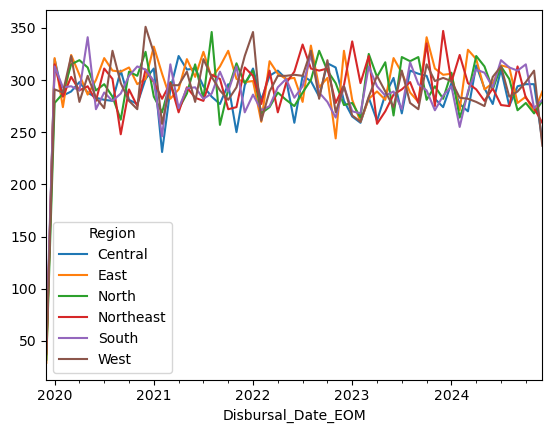

In [80]:
data_pivot.plot(kind='line')

<Axes: xlabel='Disbursal_Date_EOM'>

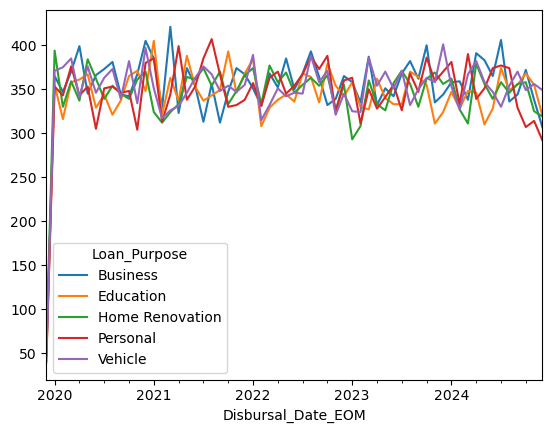

In [81]:
data_plot = data.groupby(['Loan_Purpose','Disbursal_Date_EOM'], as_index=False)['Loan_Amount'].count()
data_pivot = data_plot.pivot(index='Disbursal_Date_EOM', columns='Loan_Purpose', values='Loan_Amount')
data_pivot.plot(kind='line')

#### 12. Profitability Analysis

##### Calculate the total interest income generated across all loans

In [82]:
df_applications_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106064 entries, 0 to 106063
Data columns (total 23 columns):
 #   Column                   Non-Null Count   Dtype          
---  ------                   --------------   -----          
 0   Application_ID           106064 non-null  object         
 1   Loan_ID_x                90000 non-null   object         
 2   Customer_ID              106064 non-null  object         
 3   Application_Date         106064 non-null  datetime64[ns] 
 4   Approval_Date            90000 non-null   datetime64[ns] 
 5   Loan_Purpose             106064 non-null  object         
 6   Source_Channel           106064 non-null  object         
 7   Processing_Fee           106064 non-null  int64          
 8   Approval_Status          106064 non-null  object         
 9   Rejection_Reason         16064 non-null   object         
 10  Processing_Fee_category  106064 non-null  category       
 11  Loan_ID_y                106064 non-null  object         
 12  Lo

In [83]:
df_applications_loans['Interest_Rate_Amount'] = df_applications_loans['Interest_Rate']/100 * df_applications_loans['Loan_Amount']
df_applications_loans_Loan_Purpose = df_applications_loans.groupby('Loan_Purpose', as_index=False)['Interest_Rate_Amount'].sum()
df_applications_loans_Loan_Purpose.style.format({'Interest_Rate_Amount':'{:,.2f}'})

,Loan_Purpose,Interest_Rate_Amount
0,Business,"5,979,435,232.52"
1,Education,"5,781,789,254.55"
2,Home Renovation,"5,815,774,627.05"
3,Personal,"5,846,441,640.13"
4,Vehicle,"5,922,984,356.71"


##### Identify the most profitable loan purposes based on interest earnings. 

In [84]:
df_applications_loans_Loan_Purpose.sort_values(by='Interest_Rate_Amount', ascending=False).style.format({'Interest_Rate_Amount':'{:,.2f}'})

,Loan_Purpose,Interest_Rate_Amount
0,Business,"5,979,435,232.52"
4,Vehicle,"5,922,984,356.71"
3,Personal,"5,846,441,640.13"
2,Home Renovation,"5,815,774,627.05"
1,Education,"5,781,789,254.55"


#### 13. Geospatial Analysis

##### Map the distribution of active loans across regions.

In [85]:
df_branches.groupby('Region')['Total_Active_Loans'].sum()

Region
Central       8715
East          8929
North        11965
Northeast     5174
South         9235
West          6861
Name: Total_Active_Loans, dtype: int64

##### Compare default rates across different geographic regions.

In [86]:
df_customers_loans = pd.merge(df_customers,df_loans, on='Customer_ID', how='inner')
df_customers_loans_defaults = pd.merge(df_customers_loans, df_defaults, on='Customer_ID', how='outer')
df_customers_loans_defaults_region = df_customers_loans_defaults.groupby('Region')[['Loan_Amount','Default_Amount']].sum()
df_customers_loans_defaults_region['default_rate'] =  df_customers_loans_defaults_region['Default_Amount'] / df_customers_loans_defaults_region['Loan_Amount']*100
df_customers_loans_defaults_region

,Loan_Amount,Default_Amount,default_rate
Region,,,
Central,3.745165e+10,75335681.0,0.201155
East,3.868424e+10,87111704.0,0.225187
North,3.817697e+10,82492768.0,0.216080
Northeast,3.766689e+10,72688844.0,0.192978
South,3.793116e+10,79233783.0,0.208888
West,3.774844e+10,82190402.0,0.217732


##### Visualize the loan disbursement trends for rural vs. urban areas. 

In [87]:
df_customers_applications_df_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106064 entries, 0 to 106063
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Application_ID           106064 non-null  object        
 1   Loan_ID_x                90000 non-null   object        
 2   Customer_ID              106064 non-null  object        
 3   Application_Date         106064 non-null  datetime64[ns]
 4   Approval_Date            90000 non-null   datetime64[ns]
 5   Loan_Purpose             106064 non-null  object        
 6   Source_Channel           106064 non-null  object        
 7   Processing_Fee           106064 non-null  int64         
 8   Approval_Status          106064 non-null  object        
 9   Rejection_Reason         16064 non-null   object        
 10  Processing_Fee_category  106064 non-null  category      
 11  Full_Name                106064 non-null  object        
 12  Contact_Number  

<Axes: xlabel='Disbursal_Date_EOM'>

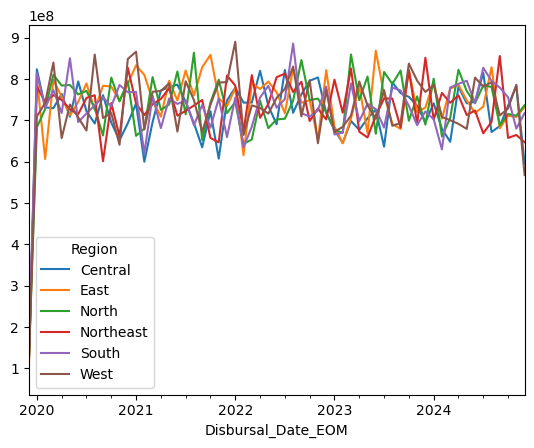

In [88]:
data = df_customers_applications_df_loans[['Region','Disbursal_Date_EOM','Loan_Amount']]
data_plot = data.groupby(['Region','Disbursal_Date_EOM'], as_index=False)['Loan_Amount'].sum()
data_pivot = data_plot.pivot(index='Disbursal_Date_EOM', columns='Region', values='Loan_Amount')
data_pivot.plot(kind='line')

#### 14. Default Trends

##### Analyze the number of defaults over time to identify patterns. 

<Axes: xlabel='Default_Date_EOM'>

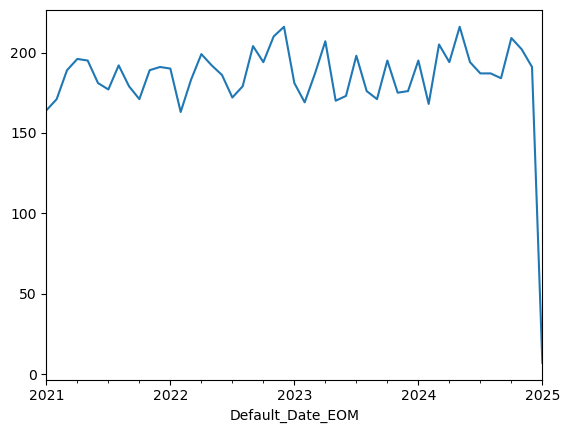

In [89]:
df_defaults_Default_Date = df_defaults
df_defaults_Default_Date['Default_Date_EOM'] = df_defaults_Default_Date['Default_Date'].dt.to_period('M').dt.to_timestamp(how='end').dt.normalize()
data_plot = df_defaults_Default_Date[['Default_Date_EOM', 'Customer_ID']]
data_plot.groupby('Default_Date_EOM')['Customer_ID'].count().plot(kind='line')

##### Calculate the average default amount for different loan purposes.

In [90]:
df_applications_defaults = pd.merge(df_applications, df_defaults, on ='Customer_ID', how='outer')
df_applications_defaults.groupby('Loan_Purpose')['Default_Amount'].sum()

Loan_Purpose
Business           86106605.0
Education          87695858.0
Home Renovation    89192140.0
Personal           86967358.0
Vehicle            89203430.0
Name: Default_Amount, dtype: float64

##### Compare default rates across customer income categories. 

In [91]:
df_applications_customer = pd.merge(df_applications, df_customers, on ='Customer_ID', how='outer')
df_applications_customer_defaults = pd.merge(df_applications_customer, df_defaults, on ='Customer_ID', how='outer')
df_applications_customer_defaults['Annual_Income_category'] = pd.cut(df_applications_customer_defaults['Annual_Income'],
                         bins = [0, 500000,1500000,3000000],
                         labels = ['Lower Middle class >5L', 'higher Middle clase 5-15L', 'high networth indivuduals >15L <30L'])
df_applications_customer_defaults_loans = pd.merge(df_applications_customer_defaults, df_loans, on ='Customer_ID', how='outer')
#df_applications_customer_defaults_loans.info()
df_applications_customer_defaults_loans_Income_group = df_applications_customer_defaults_loans.groupby('Annual_Income_category', as_index=False)[['Default_Amount','Loan_Amount']].sum()
df_applications_customer_defaults_loans_Income_group['Default_rate'] = df_applications_customer_defaults_loans_Income_group['Default_Amount'] / df_applications_customer_defaults_loans_Income_group['Loan_Amount'] *100
df_applications_customer_defaults_loans_Income_group[['Annual_Income_category','Default_rate']]

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\1124752472.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_applications_customer_defaults_loans_Income_group = df_applications_customer_defaults_loans.groupby('Annual_Income_category', as_index=False)[['Default_Amount','Loan_Amount']].sum()


,Annual_Income_category,Default_rate
0,Lower Middle class >5L,0.249115
1,higher Middle clase 5-15L,0.254337
2,high networth indivuduals >15L <30L,0.262578


#### 16. Time-Series Analysis 

##### Analyze monthly loan disbursement trends over the last 5 years. 

In [92]:
data = df_customers_applications_df_loans[['Disbursal_Date_EOM','Loan_Amount']]
data_plot = data.groupby('Disbursal_Date_EOM', as_index=False)['Loan_Amount'].sum()
data_plot.style.format({'Loan_Amount':'{:,.2f}'})

,Disbursal_Date_EOM,Loan_Amount
0,2019-12-31 00:00:00,"581,994,366.00"
1,2020-01-31 00:00:00,"4,617,026,893.00"
2,2020-02-29 00:00:00,"4,282,401,123.00"
3,2020-03-31 00:00:00,"4,712,836,073.00"
4,2020-04-30 00:00:00,"4,429,112,402.00"
5,2020-05-31 00:00:00,"4,522,829,519.00"
6,2020-06-30 00:00:00,"4,419,551,754.00"
7,2020-07-31 00:00:00,"4,429,575,451.00"
8,2020-08-31 00:00:00,"4,503,768,752.00"
9,2020-09-30 00:00:00,"4,271,657,921.00"


<Axes: xlabel='Disbursal_Date_EOM'>

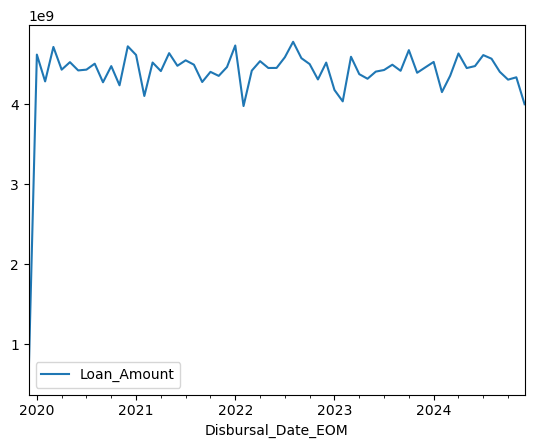

In [93]:
data_plot = data_plot.set_index('Disbursal_Date_EOM')
data_plot.plot(kind='line')

##### Identify seasonal patterns in loan applications and disbursements.

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\4129247873.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_loans_disbursal['month'] = df_loans['Disbursal_Date'].dt.month #_name()
C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\4129247873.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_loans_disbursal['year'] = df_loans['Disbursal_Date'].dt.year


<Axes: xlabel='month'>

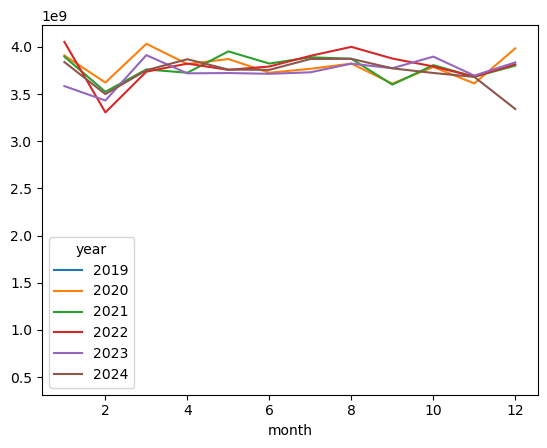

In [94]:
df_loans_disbursal = df_loans[['Loan_Amount','Disbursal_Date']]
df_loans_disbursal['month'] = df_loans['Disbursal_Date'].dt.month #_name()
df_loans_disbursal['year'] = df_loans['Disbursal_Date'].dt.year
data_plot = df_loans_disbursal.groupby(['year','month'], as_index=False)['Loan_Amount'].agg(['sum','count'])

data_pivot = data_plot.pivot(index='month', columns='year', values='sum')
data_pivot.plot(kind='line')

##### Compare monthly default rates across regions. 

<Axes: xlabel='year_month'>

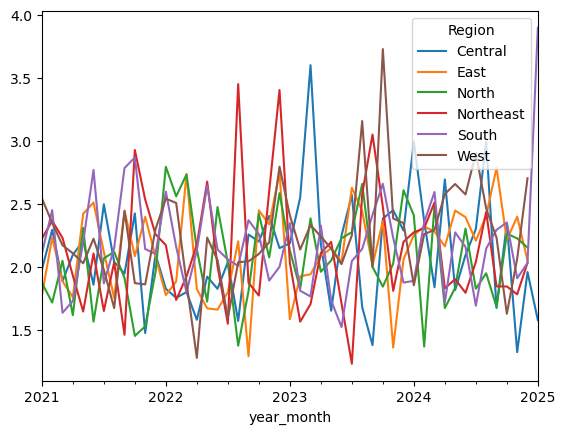

In [95]:
df_customers_loans_defaults['year_month'] = df_customers_loans_defaults['Default_Date'].dt.to_period('M')

df_customers_loans_defaults_region = df_customers_loans_defaults.groupby(['Region','year_month'], as_index=False)[['Loan_Amount','Default_Amount']].sum()

df_customers_loans_defaults_region['default_rate'] =  df_customers_loans_defaults_region['Default_Amount'] / df_customers_loans_defaults_region['Loan_Amount']*100
df_customers_loans_defaults_region


data_pivot = df_customers_loans_defaults_region.pivot(index='year_month', columns='Region', values='default_rate')
data_pivot.plot(kind='line')

#### 17. Customer Behavior Analysis 

##### Categorize customers based on their repayment behavior (e.g., always on time, occasional defaulters, frequent defaulters). 

In [96]:
df_transactions_penalty = df_transactions[df_transactions['Payment_Type']=='Penalty']
df_transactions_penalty_count = df_transactions_penalty.groupby('Customer_ID', as_index=False)['Payment_Type'].count()
df_transactions_customer_penalty = pd.merge(df_customers, df_transactions_penalty_count, on='Customer_ID', how='left')
df_transactions_customer_penalty['Payment_Type'] = df_transactions_customer_penalty['Payment_Type'].fillna(0)
df_transactions_customer_penalty['repayment_behavior'] = pd.cut(df_transactions_customer_penalty['Payment_Type'],
                                                                bins = [-1,0,5,1000],
                                                                labels = ['always on time', 'occasional defaulters', 'frequent defaulters'])
df_transactions_customer_penalty.groupby('repayment_behavior')['Customer_ID'].count()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\351151323.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_transactions_customer_penalty.groupby('repayment_behavior')['Customer_ID'].count()


repayment_behavior
always on time           20935
occasional defaulters    31526
frequent defaulters      17539
Name: Customer_ID, dtype: int64

##### Analyze patterns in loan approval and rejection reasons segmented by customer demographics. 

In [97]:
df_applications_customers_rej = pd.merge(df_applications, df_customers, on='Customer_ID', how='right')

<Axes: xlabel='Age'>

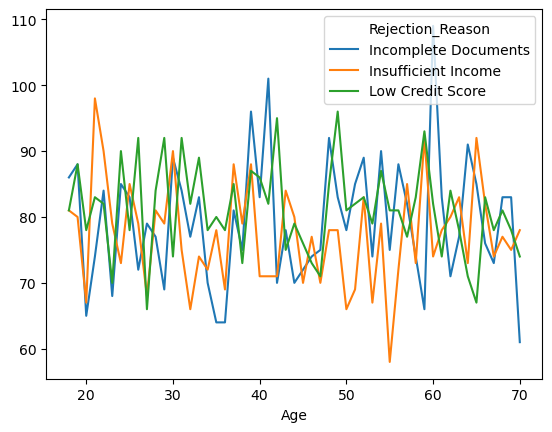

In [98]:
data_plot= df_applications_customers_rej.groupby(['Age','Rejection_Reason'], as_index=False)['Customer_ID'].count()
data_pivot = data_plot.pivot(index='Age', columns='Rejection_Reason', values='Customer_ID')
data_pivot.plot(kind='line')

<Axes: xlabel='Gender'>

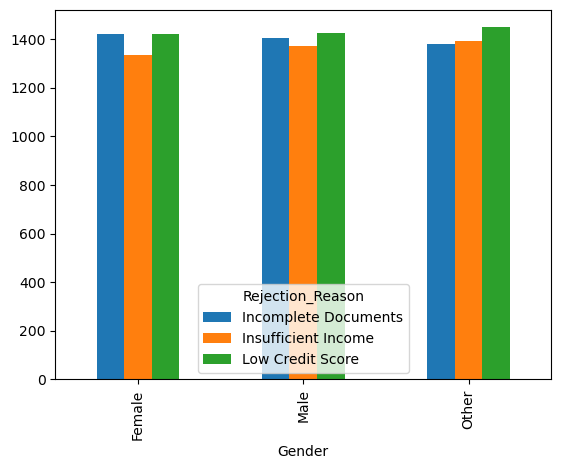

In [99]:
data_plot= df_applications_customers_rej.groupby(['Gender','Rejection_Reason'], as_index=False)['Customer_ID'].count()
data_pivot = data_plot.pivot(index='Gender', columns='Rejection_Reason', values='Customer_ID')
data_pivot.plot(kind='bar')

<Axes: xlabel='Marital_Status'>

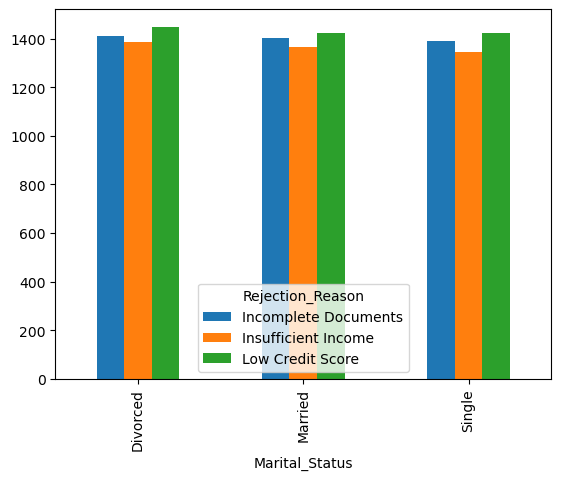

In [100]:
data_plot= df_applications_customers_rej.groupby(['Marital_Status','Rejection_Reason'], as_index=False)['Customer_ID'].count()
data_pivot = data_plot.pivot(index='Marital_Status', columns='Rejection_Reason', values='Customer_ID')
data_pivot.plot(kind='bar')

<Axes: xlabel='Employment_Status'>

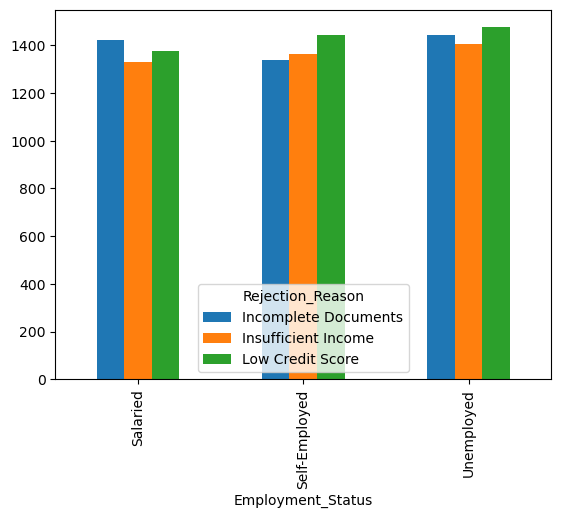

In [101]:
data_plot= df_applications_customers_rej.groupby(['Employment_Status','Rejection_Reason'], as_index=False)['Customer_ID'].count()
data_pivot = data_plot.pivot(index='Employment_Status', columns='Rejection_Reason', values='Customer_ID')
data_pivot.plot(kind='bar')

##### Identify high-value customers with consistent repayment histories. 

In [102]:
df_transactions_customer_penalty[df_transactions_customer_penalty['repayment_behavior']=='always on time'].sort_values(by='Annual_Income',ascending=False)

,Customer_ID,Full_Name,Contact_Number,Email,Address,Age,Gender,Marital_Status,Employment_Status,Annual_Income,Credit_Score,Region,Account_Tenure,Relationship_Manager_ID,Payment_Type,repayment_behavior
51465,C051466,Saanvi Bhatia,9156488010,ocomar@keer.com,"H.No. 885, Sawhney Zila, Mirzapur 793883",19,Female,Divorced,Salaried,1999927,364,North,13 Years,RM0344,0.0,always on time
31265,C031266,Aradhya Issac,3284933139,asane@gmail.com,493\nChowdhury Road\nSalem 365110,67,Female,Married,Unemployed,1999648,301,South,14 Years,RM0122,0.0,always on time
46881,C046882,Oorja Devan,5024710396,lsavant@golla.com,"H.No. 630\nBarman Marg, Yamunanagar-836222",45,Male,Divorced,Salaried,1999494,302,Central,1 Years,RM0401,0.0,always on time
8574,C008575,Rohan Kanda,910903892814,sahotaeshani@kulkarni.com,"H.No. 03, Kaul Circle\nChapra-803047",64,Male,Single,Self-Employed,1999480,823,East,5 Years,RM0297,0.0,always on time
48702,C048703,Veer Rege,5713643018,ftiwari@yahoo.com,08/590\nLata Marg\nJamshedpur-361181,64,Male,Divorced,Unemployed,1999385,676,North,8 Years,RM0266,0.0,always on time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56840,C056841,Kaira Zachariah,2121405842,aliasodhi@chowdhury-tara.biz,"H.No. 10\nDugar Marg, Hindupur 236072",24,Female,Divorced,Unemployed,200212,583,South,11 Years,RM0036,0.0,always on time
60906,C060907,Zara Wali,9198683525,sairatripathi@yahoo.com,"H.No. 032, Chacko, Indore 137151",31,Female,Single,Salaried,200129,329,North,3 Years,RM0173,0.0,always on time
16357,C016358,Bhavin Bhat,7619476376,bobalindrans@sane.net,"50/38, Chandra Path\nNavi Mumbai 681994",69,Other,Divorced,Self-Employed,200091,833,South,1 Years,RM0394,0.0,always on time
46130,C046131,Amira Raman,182755752,dkalita@chadha.net,"H.No. 63, Rajan Circle, Sagar-283929",52,Male,Divorced,Unemployed,200011,804,West,2 Years,RM0342,0.0,always on time


#### 18. Risk Assessment 
##### ● Develop a risk matrix for loan products based on Default_Amount, Loan_Term, and Interest_Rate. 

In [103]:
df_loans_defaults_data = pd.merge(df_loans, df_defaults, on='Loan_ID', how='left')
#df_loans_defaults_data['Default_Amount'].describe()

In [104]:
df_loans_defaults_data['Default_Amount_bins'] = pd.cut(df_loans_defaults_data['Default_Amount'], 
                                                        bins=5 
#                                                       bins = [0,50000,75000, 100000],
#                                                                labels = ['Low value', 'Moderate value', 'High defaults value']
                                                      )
data_plot = df_loans_defaults_data.groupby(['Collateral_Details', 'Default_Amount_bins'], as_index=False)['Default_Amount'].count()
data_plot.pivot(index='Default_Amount_bins', columns='Collateral_Details', values='Default_Amount')

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\1647732667.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_plot = df_loans_defaults_data.groupby(['Collateral_Details', 'Default_Amount_bins'], as_index=False)['Default_Amount'].count()


Collateral_Details,Property,Vehicle
Default_Amount_bins,,
"(4915.013, 24007.4]",601,561
"(24007.4, 43004.8]",616,552
"(43004.8, 62002.2]",563,639
"(62002.2, 80999.6]",630,598
"(80999.6, 99997.0]",601,633


In [105]:
df_loans_defaults_data['Loan_Term_bins'] = pd.cut(df_loans_defaults_data['Loan_Term'], bins=5)
data_plot = df_loans_defaults_data.groupby(['Collateral_Details', 'Loan_Term_bins'], as_index=False)['Loan_Amount'].count()
data_plot.pivot(index='Loan_Term_bins', columns='Collateral_Details', values='Loan_Amount')

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\4003357581.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_plot = df_loans_defaults_data.groupby(['Collateral_Details', 'Loan_Term_bins'], as_index=False)['Loan_Amount'].count()


Collateral_Details,Property,Vehicle
Loan_Term_bins,,
"(11.952, 21.6]",5911,5991
"(21.6, 31.2]",5919,6084
"(31.2, 40.8]",6035,5968
"(40.8, 50.4]",6084,6034
"(50.4, 60.0]",6121,5967


df_loans_defaults_data['Interest_Rate_bins'] = pd.cut(df_loans_defaults_data['Interest_Rate'], bins=5)
data_plot = df_loans_defaults_data.groupby(['Collateral_Details', 'Interest_Rate_bins'], as_index=False)['Loan_Amount'].count()
data_plot.pivot(index='Interest_Rate_bins', columns='Collateral_Details', values='Loan_Amount')

##### Rank loan types by risk level and suggest mitigation strategies

##### Analyze high-risk customer segments by credit score and income. 

In [108]:
df_customers_loanstatus_c1['Credit_Score_bin'] = pd.cut(df_customers_loanstatus_c1['Credit_Score'], bins=5)
data_plot = df_customers_loanstatus_c1.groupby(['Credit_Score_bin','Annual_Income_category'], as_index=False)['Loan_Amount'].count()
#df_customers_loanstatus_c1.info()
data_plot.pivot(index='Credit_Score_bin', columns='Annual_Income_category', values='Loan_Amount')

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\2026831917.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_plot = df_customers_loanstatus_c1.groupby(['Credit_Score_bin','Annual_Income_category'], as_index=False)['Loan_Amount'].count()


Annual_Income_category,Lower Middle class >5L,higher Middle clase 5-15L,high networth indivuduals >15L <30L
Credit_Score_bin,,,
"(299.45, 410.0]",3089,10075,5091
"(410.0, 520.0]",3019,10303,5035
"(520.0, 630.0]",3016,9682,4936
"(630.0, 740.0]",2893,9907,5177
"(740.0, 850.0]",2943,10098,4736


#### 19. Time to Default Analysis
##### Calculate the average time from loan disbursement to default for overdue loans.

In [119]:
df_loans_defaults_data = pd.merge(df_loans, df_defaults, on='Customer_ID', how='left')
df_loans_defaults_data['Disbursal_Date_avg'] = df_defaults['Default_Date'] - df_loans['Disbursal_Date']
#df_applications_defaults_data
df_loans_defaults_data.groupby('Default_Reason', as_index=False)['Disbursal_Date_avg'].mean()

,Default_Reason,Disbursal_Date_avg
0,Business Failure,156 days 21:18:04.337349398
1,Job Loss,163 days 15:38:30.447761194
2,Medical Emergency,269 days 12:56:28.235294116
3,Other,148 days 14:49:36


##### Identify loan purposes with the shortest time to default.

In [120]:
df_applications_loans_defaults_data = pd.merge(df_applications, df_loans_defaults_data, on='Customer_ID', how='left')
df_applications_loans_defaults_data.groupby('Loan_Purpose', as_index=False)['Disbursal_Date_avg'].mean()

,Loan_Purpose,Disbursal_Date_avg
0,Business,187 days 16:41:20.846968238
1,Education,215 days 07:11:30.626517728
2,Home Renovation,167 days 16:48:24.662226450
3,Personal,181 days 17:49:51.970466082
4,Vehicle,184 days 00:22:26.287809350


##### Compare the time to default across customer demographics. 

In [124]:
df_customers_applications_loans_defaults_data = pd.merge(df_customers, df_applications_loans_defaults_data, on='Customer_ID', how='left')

In [125]:
df_customers_applications_loans_defaults_data['Age_bins'] = pd.cut(df_customers_applications_loans_defaults_data['Age'],bins=10)
df_customers_applications_loans_defaults_data.groupby('Age_bins', as_index=False)['Disbursal_Date_avg'].mean()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\4035899162.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_customers_applications_loans_defaults_data.groupby('Age_bins', as_index=False)['Disbursal_Date_avg'].mean()


,Age_bins,Disbursal_Date_avg
0,"(17.948, 23.2]",163 days 12:31:21.468830060
1,"(23.2, 28.4]",211 days 04:33:10.467111536
2,"(28.4, 33.6]",185 days 01:46:27.212787212
3,"(33.6, 38.8]",172 days 16:33:49.430051814
4,"(38.8, 44.0]",168 days 18:22:46.153846154
5,"(44.0, 49.2]",199 days 19:45:16.564417178
6,"(49.2, 54.4]",160 days 05:23:31.835506520
7,"(54.4, 59.6]",209 days 10:57:05.242718448
8,"(59.6, 64.8]",213 days 23:09:49.830508476
9,"(64.8, 70.0]",189 days 10:03:11.587982832


In [126]:
df_customers_applications_loans_defaults_data.groupby('Gender', as_index=False)['Disbursal_Date_avg'].mean()

,Gender,Disbursal_Date_avg
0,Female,190 days 21:26:53.722710518
1,Male,179 days 07:00:20.524515394
2,Other,191 days 02:16:34.990149170


In [127]:
df_customers_applications_loans_defaults_data.groupby('Marital_Status', as_index=False)['Disbursal_Date_avg'].mean()

,Marital_Status,Disbursal_Date_avg
0,Divorced,162 days 08:24:41.989708404
1,Married,200 days 16:51:16.037631434
2,Single,197 days 21:59:51.714614500


In [128]:
df_customers_applications_loans_defaults_data.groupby('Employment_Status', as_index=False)['Disbursal_Date_avg'].mean()

,Employment_Status,Disbursal_Date_avg
0,Salaried,185 days 18:20:27.062517842
1,Self-Employed,196 days 02:25:42.566421708
2,Unemployed,179 days 11:49:14.496757824


In [129]:
df_customers_applications_loans_defaults_data['Annual_Income_bins'] = pd.cut(df_customers_applications_loans_defaults_data['Annual_Income'],bins=5)
df_customers_applications_loans_defaults_data.groupby('Annual_Income_bins', as_index=False)['Disbursal_Date_avg'].mean()

C:\Users\Jintu\AppData\Local\Temp\ipykernel_17772\61471012.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_customers_applications_loans_defaults_data.groupby('Annual_Income_bins', as_index=False)['Disbursal_Date_avg'].mean()


,Annual_Income_bins,Disbursal_Date_avg
0,"(198205.055, 559994.0]",172 days 16:01:33.680297398
1,"(559994.0, 919983.0]",188 days 09:11:50.107948970
2,"(919983.0, 1279972.0]",208 days 15:20:05.700712588
3,"(1279972.0, 1639961.0]",173 days 07:23:14.042553192
4,"(1639961.0, 1999950.0]",192 days 19:40:09.917355372


#### 20. Transaction Pattern Analysis 
##### ● Identify customers with irregular repayment patterns.

In [147]:
data_dates_diff['cus_diff'] = df_transactions.groupby('Customer_ID', as_index=False)['Transaction_Date'].diff()
data_dates_diff[['Customer_ID','cus_diff']].sort_values(by='cus_diff', ascending=False)

,Customer_ID,cus_diff
25166,C034993,1801 days
23773,C033075,1793 days
31453,C043626,1792 days
44549,C061680,1788 days
15953,C022196,1782 days
...,...,...
50581,C069989,NaT
50583,C069991,NaT
50584,C069993,NaT
50585,C069994,NaT


##### ● Analyze penalty payments as a proportion of total transactions.

In [159]:
data_cust_penalty = df_transactions.groupby(['Customer_ID','Payment_Type'], as_index=False)['Loan_ID'].count()
data_cust_penalty = data_cust_penalty.rename(columns={'Loan_ID':'count_of_Penalty_payments'})
#data_cust_penalty
data_cust_penalty = data_cust_penalty[data_cust_penalty['Payment_Type']=='Penalty'][['Customer_ID','count_of_Penalty_payments']]
#data_cust_penalty

In [170]:
data_cust_total = df_transactions.groupby(['Customer_ID'], as_index=False)['Loan_ID'].count()
#data_cust_total
data_cust_total = data_cust_total.rename(columns={'Loan_ID':'count_of_Total_payments'})
#data_cust_total

In [171]:
data_cust_penalty_by_total = pd.merge(data_cust_total,data_cust_penalty,on='Customer_ID',how='left')
data_cust_penalty_by_total['penalty_by_total'] = data_cust_penalty_by_total['count_of_Penalty_payments'] / data_cust_penalty_by_total['count_of_Total_payments']
data_cust_penalty_by_total.sort_values(by='count_of_Penalty_payments',ascending=False)

,Customer_ID,count_of_Total_payments,count_of_Penalty_payments,penalty_by_total
21262,C029631,51,31.0,0.607843
3955,C005453,42,30.0,0.714286
33380,C046271,51,30.0,0.588235
1870,C002589,53,29.0,0.547170
15583,C021671,38,29.0,0.763158
...,...,...,...,...
50460,C069816,2,NaN,NaN
50502,C069882,5,NaN,NaN
50562,C069962,3,NaN,NaN
50575,C069979,2,NaN,NaN


##### ● Compare transaction amounts for overdue vs. non-overdue loans. 

In [190]:
df_loan_transactions_data = pd.merge(df_loans, df_transactions,on='Loan_ID', how='inner')
df_loan_transactions_yesoverdue_loans = df_loan_transactions_data[df_loan_transactions_data['Payment_Type']=='Penalty'][['Loan_ID','Amount']].rename(columns={'Amount':'Amounts_of_yesOverdue_payments'})
df_loan_transactions_nonoverdue_loans = df_loan_transactions_data[df_loan_transactions_data['Payment_Type']!='Penalty'][['Loan_ID','Amount']].rename(columns={'Amount':'Amounts_of_nonOverdue_payments'})
df_loan_transactions_combined = pd.merge(df_loan_transactions_yesoverdue_loans, df_loan_transactions_nonoverdue_loans, on='Loan_ID', how='outer')

<Axes: ylabel='Frequency'>

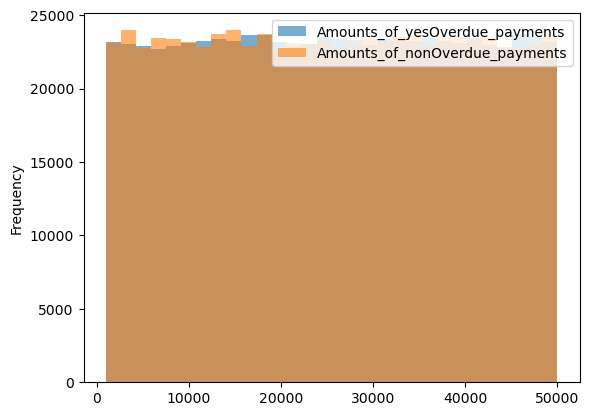

In [194]:
df_loan_transactions_combined[['Amounts_of_yesOverdue_payments','Amounts_of_nonOverdue_payments']].plot(kind='hist', alpha=0.6, bins=30)